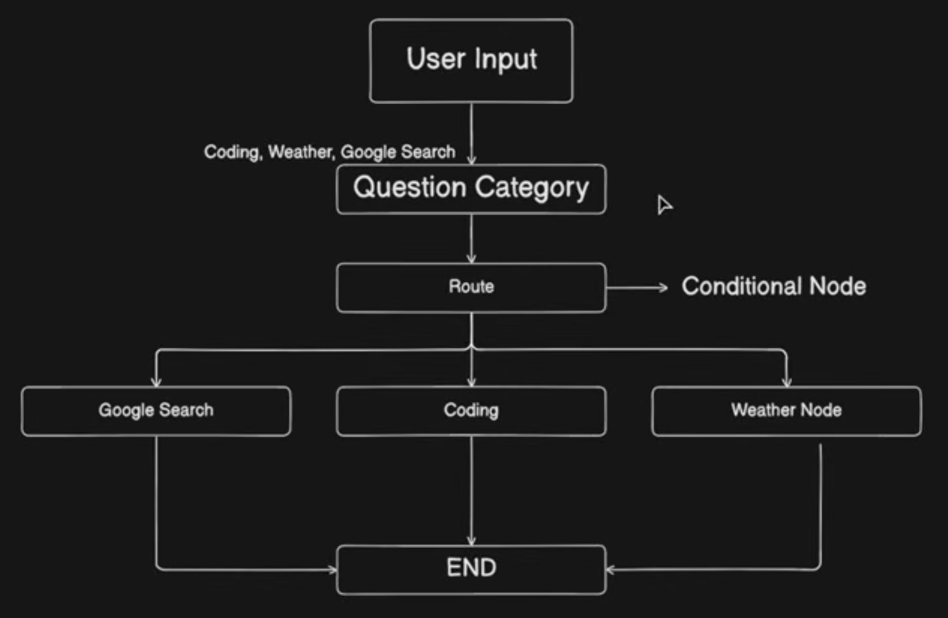

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal 


In [3]:
#COding, google_search, weather

class FlowState(BaseModel):
    question : str = Field(description="USer ask Question")
    category : Literal["coding", "google_search", "weather"] = Field(default = "google_search")
    answer : str = Field(default = "")
    


In [4]:
class QuestionCategory(BaseModel):
    category : Literal["coding", "google_search", "weather"] = Field(default = "google_search", description="Category of the question")

In [5]:
llm = ChatGroq(model = "llama-3.3-70b-versatile")

In [8]:
def check_question_category(state: FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of the question, question is : {state.question}. If you are not sure then just give 'google_search' as category. ")
    state.category = res.category
    return state 


In [13]:
def route(state : FlowState) -> Literal["coding", "google_search", "weather"]:
    return state.category

In [15]:
def coding_node(state : FlowState) -> FlowState:
    res = llm.invoke(f"You are a coding expert, answer the question : {state.question}")
    state.answer = res
    return state

def weather_node(state : FlowState) -> FlowState:
    print("Weather Node")
    return state

def google_search_node(state : FlowState) -> FlowState:
    print("Google Node")
    return state

In [18]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", check_question_category)
graph.add_node("weather", check_question_category)
graph.add_node("google_search", check_question_category)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

graph = graph.compile()

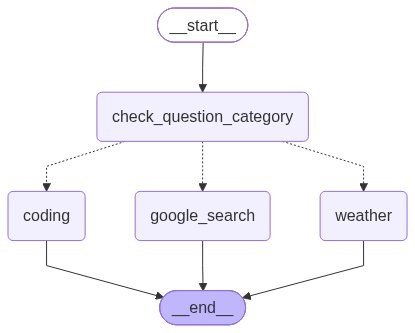

In [19]:
from IPython.display import Image 
Image(graph.get_graph().draw_mermaid_png())